# Procesamiento e Ingeniería de Características

### Se importan las librerias necesarias

In [1]:
#pip install xgboost

In [2]:
#pip install prophet

In [3]:
#pip install pandas

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.style.use('ggplot')

### Leemos los 3 datasets

In [7]:
df_2023 = pd.read_csv('sample_data/2023.csv')
df_2024 = pd.read_csv('sample_data/2024.csv')
df_2025 = pd.read_csv('sample_data/2025.csv')

### Consulta de la información inicial de cada dataset

Aqui se puede observar que los tres dataset cuentan con la misma información, lo cual nos permite realizar la concatenación de los mismos

In [8]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43338 entries, 0 to 43337
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Channel               43338 non-null  object
 1   Material Description  43338 non-null  object
 2   Category              43338 non-null  object
 3   202301                43338 non-null  int64 
 4   202302                43338 non-null  int64 
 5   202303                43338 non-null  int64 
 6   202304                43338 non-null  int64 
 7   202305                43338 non-null  int64 
 8   202306                43338 non-null  int64 
 9   202307                43338 non-null  int64 
 10  202308                43338 non-null  int64 
 11  202309                43338 non-null  int64 
 12  202310                43338 non-null  int64 
 13  202311                43338 non-null  int64 
 14  202312                43338 non-null  int64 
 15  202313                43338 non-null

In [9]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37035 entries, 0 to 37034
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Channel               37035 non-null  object
 1   Material Description  37035 non-null  object
 2   Category              37035 non-null  object
 3   202401                37035 non-null  int64 
 4   202402                37035 non-null  int64 
 5   202403                37035 non-null  int64 
 6   202404                37035 non-null  int64 
 7   202405                37035 non-null  int64 
 8   202406                37035 non-null  int64 
 9   202407                37035 non-null  int64 
 10  202408                37035 non-null  int64 
 11  202409                37035 non-null  int64 
 12  202410                37035 non-null  int64 
 13  202411                37035 non-null  int64 
 14  202412                37035 non-null  int64 
 15  202413                37035 non-null

In [10]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25239 entries, 0 to 25238
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Channel               25239 non-null  object 
 1   Material Description  25239 non-null  object 
 2   Category              25239 non-null  object 
 3   202501                25239 non-null  object 
 4   202502                25239 non-null  object 
 5   202503                25239 non-null  object 
 6   202504                25239 non-null  object 
 7   202505                25239 non-null  object 
 8   202506                25239 non-null  object 
 9   202507                25239 non-null  object 
 10  202508                25239 non-null  object 
 11  202509                25239 non-null  object 
 12  202510                25239 non-null  object 
 13  202511                25239 non-null  object 
 14  202512                25239 non-null  object 
 15  202513             

### Verificación de duplicados

Al verificar los registros completamente duplicados dentro de los archivos históricos. Estos duplicados correspondían a filas donde coincidían exactamente todas las variables del registro.

Desde la lógica del negocio, este comportamiento no resulta coherente, ya que no tendría sentido que un mismo cliente registrara exactamente el mismo producto, en la misma categoría y con idénticos valores semanales en un registro separado. En este contexto, dichos registros no representan nuevas transacciones ni eventos distintos, sino una repetición exacta de la información. Mantener estos duplicados podría generar distorsiones en el análisis, tales como: Sobreestimación de ventas, Incremento artificial de inventarios Sesgo en métricas estadísticas y tal vez afectar el entrenamiento incorrecto del modelo predictivo.

Por esta razón, se decidió eliminar los registros duplicados antes de realizar la transformación longitudinal de los datos (melt()).

Esta decisión es especialmente importante porque, al aplicar melt(), cada fila original se expande en múltiples registros semanales. Si los duplicados se conservaran antes de esta transformación, el problema se multiplicaría significativamente, generando una gran cantidad de registros redundantes y amplificando el sesgo en el análisis posterior.

In [11]:
df_2023.duplicated().sum()

np.int64(1741)

In [12]:
df_2024.duplicated().sum()

np.int64(1620)

In [13]:
df_2025.duplicated().sum()

np.int64(734)

In [14]:
df_2023 = df_2023.drop_duplicates()
df_2024 = df_2024.drop_duplicates()
df_2025 = df_2025.drop_duplicates()

### Converción a valor numerico las columnas de semanas

Es necesario realizar este paso antes de realizar el groupby, ya que al no hacerlo en algunas columnas se concaten pero strings y luego estos al pasarlo a numerico quedan como "NaN". Aqui ocurre algo particular con el dataset del 2025, pues las columnas de semanas vienen formateadas como texto con comas para separar miles (ej. "1,142.0 "), Al no tratar esto se convertiria en NaN y por ende se le daria el valor de 0. Ademas algo adicional con este dataset es que solo tiene informacion hasta la semana 33, pues apartir de esta columna hasta la 52 solo contiene 0.

In [15]:
columnas_semanas = [col for col in df_2025.columns if col.startswith('2025')]

for col in columnas_semanas:

    mask = (
        df_2025[col]
        .astype(str)
        .str.contains(',', na=False)
    )

    if mask.any():

        print(f"\n{'='*50}")
        print(f"Columna: {col}")
        print(f"{'='*50}")

        ejemplos = df_2025.loc[
            mask,
            ['Channel', 'Material Description', 'Category', col]
        ].head(5)

        print(ejemplos)

        break


Columna: 202501
        Channel                Material Description      Category    202501
2567  CUSTOMER7  MOBILE,SM-A155M/DSN,LIGHT BLUE,LTC  Channel Inv.  1,142.0 
2570  CUSTOMER7  MOBILE,SM-A155M/DSN,LIGHT BLUE,LTC  Channel Inv.  1,672.0 
2582  CUSTOMER7      MOBILE,SM-A155M/DSN,YELLOW,LTC  Channel Inv.  1,443.0 
2630  CUSTOMER7   MOBILE,SM-A356E/DS,LIGHT BLUE,LTC  Channel Inv.  1,267.0 
2768  CUSTOMER7        MOBILE,SM-M556B/DS,BLACK,COO  Channel Inv.  1,479.0 


In [16]:
id_vars = [
    'Channel',
    'Material Description',
    'Category'
]

In [17]:
week_cols23 = [
    col for col in df_2023.columns
    if col not in id_vars
]

In [18]:
week_cols24 = [
    col for col in df_2024.columns
    if col not in id_vars
]

In [19]:
week_cols25 = [
    col for col in df_2025.columns
    if col not in id_vars
]

In [20]:
for col in week_cols23:
    df_2023[col] = pd.to_numeric(
        df_2023[col],
        errors='coerce'
    )

In [21]:
for col in week_cols24:
    df_2024[col] = pd.to_numeric(
        df_2024[col],
        errors='coerce'
    )

In [22]:
for col in week_cols25:
    df_2025[col] = df_2025[col].astype(str).str.replace(',', '', regex=False).str.strip()
    df_2025[col] = pd.to_numeric(df_2025[col], errors='coerce')


### Agrupamos por Channel, Material Description y Category

Durante el análisis exploratorio se identificó que múltiples registros compartían la misma combinación de:

Cliente (Channel)
Producto (Material Description)
Categoría (Category)

pero distribuían los valores semanales en filas separadas. Si estos registros se transformaban directamente mediante melt(), se generaban múltiples observaciones para una misma combinación de cliente, producto, categoría y semana, provocando redundancia de registros y posibles inconsistencias en el análisis temporal.

Por esta razón, antes de realizar la transformación longitudinal, se aplicó un proceso de consolidación utilizando groupby sobre las variables descriptivas principales y realizando una suma de los valores semanales.

In [23]:
# Columnas clave
group_cols = [
    'Channel',
    'Material Description',
    'Category'
]

In [24]:
# Agrupar y sumar semanas
df_2023 = (
    df_2023
    .groupby(group_cols, as_index=False)
    .sum()
)

In [25]:
# Agrupar y sumar semanas
df_2024 = (
    df_2024
    .groupby(group_cols, as_index=False)
    .sum()
)

In [26]:
# Agrupar y sumar semanas
df_2025 = (
    df_2025
    .groupby(group_cols, as_index=False)
    .sum()
)

### Concatenación de los 3 datasets

Como se pudo observar en cada dataset la fecha que esta distribuida por semanas y cada uan de ellas es una columna covirtiendolo asi en un formato ancho, por lo tanto se opta por convertir el df a formato largo, alli creamos las columnas Semana y Valor. Con este cambio logramos unificar los tres datasets en uno solo.

In [27]:
id_vars = ['Channel', 'Material Description', 'Category']

In [28]:
df_2023_long = df_2023.melt(
    id_vars=id_vars,
    var_name='Semana',
    value_name='Valor'
)

In [29]:
df_2024_long = df_2024.melt(
    id_vars=id_vars,
    var_name='Semana',
    value_name='Valor'
)

In [30]:
df_2025_long = df_2025.melt(
    id_vars=id_vars,
    var_name='Semana',
    value_name='Valor'
)

In [31]:
df_total = pd.concat(
    [df_2023_long, df_2024_long, df_2025_long],
    ignore_index=True
)

In [32]:
df_total.isnull().sum()

,0
Channel,0
Material Description,0
Category,0
Semana,0
Valor,0


### Creacion de columnas y cambio de tipo de dato





- En esta etapa, la columna correspondiente a la fecha fue dividida en dos nuevas variables: Año y Semana. Esta transformación permite trabajar de manera más eficiente el análisis temporal, facilitando el estudio de tendencias, estacionalidad y comportamiento semanal de los datos.
- Posteriormente, la columna Valor fue convertida al tipo de dato entero (int), ya que representa cantidades de productos, ventas o inventario, es decir, valores discretos que no requieren precisión decimal.
- También se realizó un análisis estructural sobre la columna Material Description. Durante esta revisión se identificó que los registros no seguían una única estructura, sino múltiples formatos dependiendo del tipo de producto. Debido a esto, dividir toda la columna en múltiples variables habría generado una gran cantidad de valores nulos (NaN) y una estructura poco consistente. Por esta razón, se decidió extraer únicamente el tipo de producto, conservando así la información más relevante y homogénea para el análisis posterior
- Se removio las semanas sin datos reales en el 2025, es decir desde la 34 a la 52.

In [33]:
df_total['Año'] = df_total['Semana'].astype(str).str[:4].astype(int)

In [34]:
df_total['Semana'] = (df_total['Semana'].astype(str).str[-2:].astype(int))

In [35]:
df_total['Valor'] = df_total['Valor'].astype(int)

In [36]:
df_total['Material Description'].str.count(',').value_counts().sort_index()

,count
Material Description,
0,6552
1,2496
2,729768
3,2095860
4,1576224
5,199056


In [37]:
for n in sorted(df_total['Material Description'].str.count(',').unique()):
    print(f"\n=== {n} comas ===")

    ejemplos = (
        df_total[
            df_total['Material Description'].str.count(',') == n
        ]['Material Description']
        .drop_duplicates()
        .head(5)
    )

    print(ejemplos.to_list())


=== 0 comas ===
['HTS_DVD', 'MAX-A55T', 'MINI COMPO', 'MINI COMPO_DVD', 'BLACK/SILVER 2 TONE SPK APPLY FROM MAX-X']

=== 1 comas ===
['60W/CH, CD', 'DVD PLAYER,', '360MM, DIVX PLAYBACK', 'CHR,SETIN']

=== 2 comas ===
['MINI COMPONENT,MX-T50,COLOMBIA', 'MINI COMPONENT,MX-T70,COLOMBIA', 'RFD,664.0,127V 60HZ', 'RLF,313.0,120V 60HZ', 'RSS,21.8,120V 60HZ']

=== 3 comas ===
['MOBILE,SM-A032M/DS,BLACK,LTC', 'MOBILE,SM-A035M/DS,BLACK,LTC', 'MOBILE,SM-A035M/DS,BLUE,LTC', 'MOBILE,SM-A135M/DS,BLACK,LTC', 'MOBILE,SM-A225M/DS,BLACK,LTC']

=== 4 comas ===
['LED TV,UN32J4290AK,32,COLOMBIA,UWE70/U32', 'LED TV,UN32T4300AK,32,COLOMBIA,UWM01/U32', 'LED TV,UN40T5290AK,40,COLOMBIA,UWM00/U40', 'LED TV,UN43AU7000K,43,COLOMBIA,UWS10/U43', 'LED TV,UN43BU8000K,43,COLOMBIA,UNS10/U43']

=== 5 comas ===
['RAC,5.3,KW,SET,CO,R410A', 'RAC,7.0,KW,SET,CO,R410A', 'RAC,3.0,KW,SET,CO,R410A', 'RAC,3.5,KW,SET,CO,R410A', 'RAC,2.6,KW,SET,CO,R410A']


In [38]:
df_total['TipoProducto'] = (
    df_total['Material Description']
    .str.split(',')
    .str[0]
    .str.strip()
)

In [39]:
# Crear fecha usando Año + Semana ISO
# Se usa el lunes de cada semana como referencia
df_total['Fecha'] = pd.to_datetime(
    df_total['Año'].astype(str) +
    df_total['Semana'].astype(str).str.zfill(2) +
    '1',
    format='%G%V%u'
)

In [40]:
df_total['Mes'] = df_total['Fecha'].dt.month


In [41]:
df_total = df_total[~((df_total['Año'] == 2025) & (df_total['Semana'] >= 34))].reset_index(drop=True)

# Analísis Estadistico y de probababilidad

In [42]:
print(df_total.shape)

(4206567, 9)


### Estadistica Descriptiva

El dataset final quedó conformado por aproximadamente 4.2 millones de registros, correspondientes a información semanal de ventas, inventario y distribución de productos entre los años 2023 y 2025.

En la variable Semana, se observa un rango entre 1 y 52, lo cual confirma que los datos fueron organizados correctamente bajo una estructura semanal anual. Además, la media de 26.5 indica una distribución equilibrada entre las semanas del año.

Respecto a la variable Valor, se identificó un promedio de aproximadamente 17.95 unidades por registro; sin embargo, la desviación estándar es bastante alta (206.8), lo que evidencia una gran dispersió

n en los datos y diferencias significativas entre registros con ventas bajas y otros con volúmenes muy altos.

También se encontraron valores negativos, con un mínimo de -2300. Esto podría estar asociado a devoluciones, ajustes de inventario, cancelaciones o correcciones operativas dentro del sistema empresarial.

Por otro lado, el valor máximo registrado fue de 43,484 unidades, lo que indica la existencia de picos elevados de movimiento comercial en determinados productos o periodos específicos.

In [43]:
df_total.describe()

,Semana,Valor,Año,Fecha,Mes
count,4.206567e+06,4.206567e+06,4.206567e+06,4206567,4.206567e+06
mean,2.491773e+01,2.211186e+01,2.023710e+03,2024-03-02 19:08:33.937280512,6.106842e+00
min,1.000000e+00,-3.997000e+03,2.023000e+03,2023-01-02 00:00:00,1.000000e+00
25%,1.200000e+01,0.000000e+00,2.023000e+03,2023-07-17 00:00:00,3.000000e+00
50%,2.400000e+01,0.000000e+00,2.024000e+03,2024-02-05 00:00:00,6.000000e+00
75%,3.700000e+01,0.000000e+00,2.024000e+03,2024-10-07 00:00:00,9.000000e+00
max,5.200000e+01,4.348400e+04,2.025000e+03,2025-08-11 00:00:00,1.200000e+01
std,1.467524e+01,2.389670e+02,7.342248e-01,NaN,3.377438e+00


### Cuartiles y Pecentiles

Los cuartiles muestran que:

- El 25% de los registros tienen valor 0.
- El 50% de los registros tienen valor 0.
- El 75% de los registros tienen valor 0.

Esto significa que más del 75% de los registros no presentan movimiento comercial en una semana determinada. En otras palabras, el dataset es altamente disperso y contiene una gran cantidad de semanas sin ventas o sin movimientos de inventario.

Sin embargo, al analizar los percentiles superiores se observa que:

- El 90% de los registros tienen valores menores o iguales a 10.
- El 95% son menores o iguales a 42.
- El 99% son menores o iguales a 338.

Esto indica que la mayoría de los movimientos comerciales son relativamente pequeños, mientras que solo una pequeña proporción de registros presenta valores extremadamente altos.

In [44]:
print("\n")
print("Cuartiles:")

print(df_total['Valor'].quantile([0.25, 0.5, 0.75]))

print("\n")
print("Percentiles:")

print(df_total['Valor'].quantile([0.10, 0.90, 0.95, 0.99]))




Cuartiles:
0.25    0.0
0.50    0.0
0.75    0.0
Name: Valor, dtype: float64


Percentiles:
0.10      0.0
0.90     13.0
0.95     50.0
0.99    416.0
Name: Valor, dtype: float64


### Analisi de frecuencia

El análisis de frecuencias evidencia que el valor más común es 0, con más de 3.1 millones de registros. Esto confirma nuevamente que existen muchas semanas sin actividad para determinados productos o categorías.

Posteriormente, los valores más frecuentes corresponden a cantidades pequeñas como 1, 2, 3 y 4 unidades, lo cual sugiere un comportamiento típico de demanda discreta y posiblemente intermitente.

In [45]:
print("\n")
print("Top 10 valores mas frecuentes:")

print(df_total['Valor'].value_counts().head(10))



Top 10 valores mas frecuentes:
Valor
0     3159742
1      194165
2       98204
3       66131
4       51063
5       46039
6       31505
7       25932
10      24183
8       23143
Name: count, dtype: int64


### Analisis por categoria

El dataset contiene tres categorías principales:

- Channel Inv.
- Cust. Sales
- Sell-in

La categoría Channel Inv. presenta el promedio más alto (53.49), así como la mayor desviación estándar, lo que indica una variabilidad considerable en los niveles de inventario de canal.

Por otro lado, Cust. Sales y Sell-in muestran promedios mucho menores, un poco más de 6 unidades, reflejando movimientos comerciales más moderados y constantes.

Además, las tres categorías presentan medianas iguales a 0, lo que refuerza el comportamiento altamente disperso del dataset y la presencia de numerosos registros sin movimiento.

In [46]:
print("\n")
print("Analisis por categoria:")

categoria_stats = (
    df_total
    .groupby('Category')['Valor']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max',
        'sum'
    ])
)

print(categoria_stats)



Analisis por categoria:
                count       mean  median         std   min    max       sum
Category                                                                   
Channel Inv.  1402189  53.491454     0.0  394.830546  -523  43484  75005129
Cust. Sales   1402189   6.462865     0.0   61.432415 -1517  17162   9062158
Sell-in       1402189   6.381247     0.0  100.864784 -3997  27518   8947714


### Analisis por año

Al analizar el comportamiento anual, se observa que:

2023 y 2024 presentan promedios similares, cercanos a 20 unidades.
2025 muestra una disminución importante en el promedio, alcanzando aproximadamente 19 unidades.

Esta diferencia podría explicarse porque el dataset de 2025 aún no contiene la totalidad del año o porque existen cambios operativos, comerciales o de demanda durante ese periodo.

También se observa que 2023 y 2024 presentan una dispersión mucho mayor que 2025, evidenciada por su desviación estándar más alta.

In [47]:
print("\n")
print("Analisis por año:")

anio_stats = (
    df_total
    .groupby('Año')['Valor']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max',
        'sum'
    ])
)

print(anio_stats)



Analisis por año:
        count       mean  median         std   min    max       sum
Año                                                                
2023  1921296  19.665839     0.0  246.395140 -2300  43484  37783898
2024  1584648  21.284589     0.0  219.931661 -1000  27552  33728581
2025   700623  30.690574     0.0  258.620179 -3997  15006  21502522


### Analisis por tipo de producto

El análisis de TipoProducto muestra que los productos móviles (MOBILE) representan la categoría con mayor cantidad de registros, superando 1.2 millones de observaciones.

Posteriormente destacan categorías como:

- LED TV
- QLED TV
- TABLET
- RTF
- AV RECEIVER

Esto evidencia una fuerte concentración del dataset en productos tecnológicos y electrónicos de consumo.

Además, la gran cantidad de registros asociados a productos móviles podría convertir esta categoría en una de las más relevantes para futuros análisis predictivos o modelos de forecasting.

In [48]:
print("\n")
print("Top 15 tipos de productos:")

print(
    df_total['TipoProducto']
    .value_counts()
    .head(15)
)



Top 15 tipos de productos:
TipoProducto
MOBILE            1283913
LED TV             694575
QLED TV            386115
TABLET             210705
RTF                169524
AV RECEIVER        152898
OWM                143460
MON                100455
FWM                 92166
RAC                 89415
MWO(COMMON)         82668
RFD                 80787
RSS                 79743
LFD                 67479
MINI COMPONENT      64056
Name: count, dtype: int64


### Analisis por graficos

#### Rotación de Inventarios: General vs Puntos Específicos (Ventas / Inventario)

La rotación se calcula como Sell-in ÷ Channel Inv. por semana. La línea negra (global) suele moverse en un rango moderado (en promedio cercano a 0,10–0,13), con variaciones semana a semana. Las líneas punteadas por canal muestran que no todos los puntos rotan igual: algunos clientes tienen picos o caídas más marcadas que el promedio general. Picos altos indican semanas donde las ventas al canal fueron altas respecto al inventario registrado; caídas sugieren inventario alto o ventas bajas en ese periodo.

Este grafico nos sirve para ver si la cadena, en conjunto y por cliente clave, está “moviendo” inventario de forma eficiente y detectar canales con comportamiento distinto al resto.

In [49]:

# ROTACIÓN DE INVENTARIO GENERAL Y POR PUNTO ESPECÍFICO (CANAL)
inventario = (
    df_total[df_total['Category'] == 'Channel Inv.']
    .groupby('Fecha')['Valor']
    .sum()
)

ventas = (
    df_total[df_total['Category'] == 'Sell-in']
    .groupby('Fecha')['Valor']
    .sum()
)

rotacion = (ventas / inventario).reset_index()
rotacion.columns = ['Fecha', 'Rotacion']

# Rotación por punto específico (Canal - Top 5 con más volumen)
top_clientes_nombres = (
    df_total
    .groupby('Channel')['Valor']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

df_top_channels = df_total[df_total['Channel'].isin(top_clientes_nombres)]

inventario_ch = (
    df_top_channels[df_top_channels['Category'] == 'Channel Inv.']
    .groupby(['Fecha', 'Channel'])['Valor']
    .sum()
)

ventas_ch = (
    df_top_channels[df_top_channels['Category'] == 'Sell-in']
    .groupby(['Fecha', 'Channel'])['Valor']
    .sum()
)

rotacion_ch = (ventas_ch / inventario_ch).reset_index()
rotacion_ch.columns = ['Fecha', 'Channel', 'Rotacion']


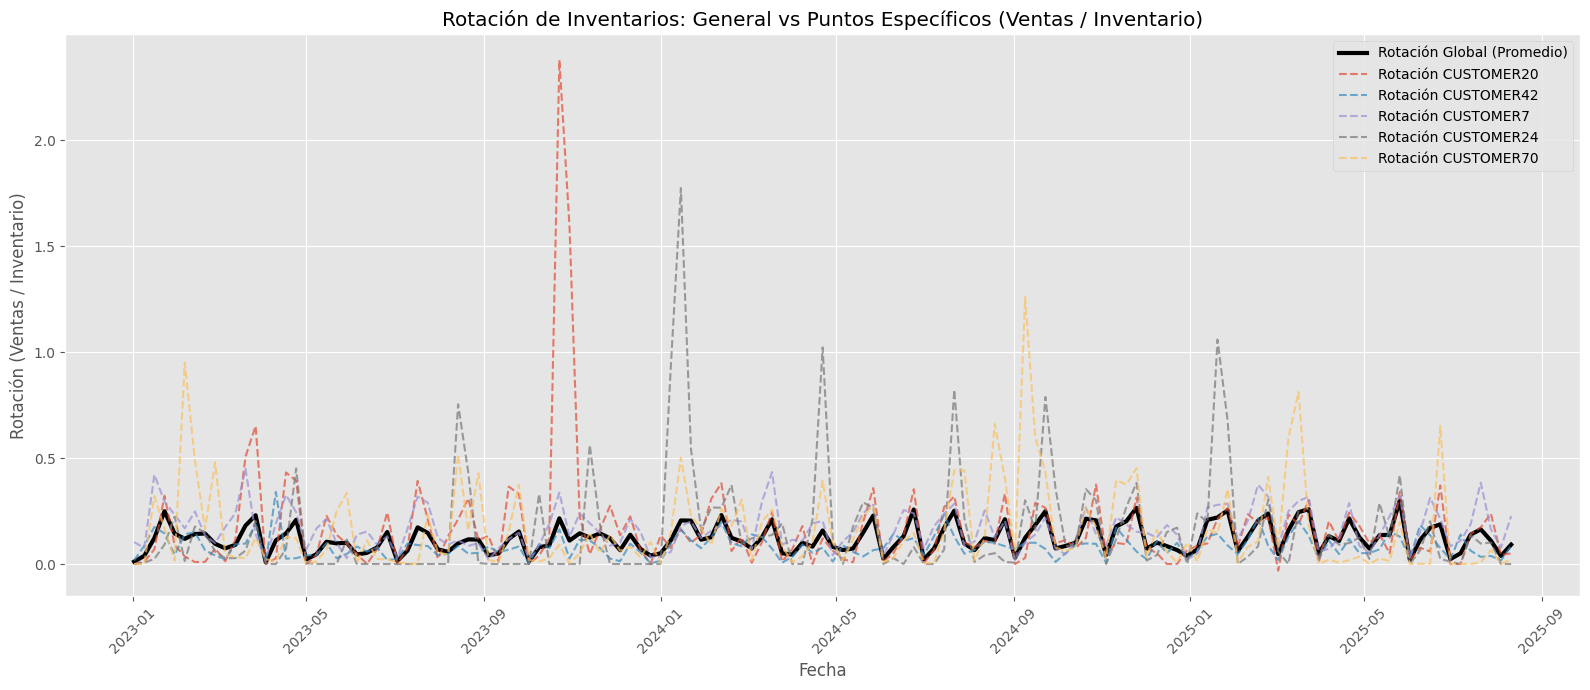

In [50]:
plt.figure(figsize=(16, 7))

# Graficar rotación global
plt.plot(
    rotacion['Fecha'],
    rotacion['Rotacion'],
    label='Rotación Global (Promedio)',
    linewidth=3,
    color='black'
)

# Graficar rotación para el top de canales
for channel in top_clientes_nombres:
    ch_data = rotacion_ch[rotacion_ch['Channel'] == channel]
    plt.plot(
        ch_data['Fecha'],
        ch_data['Rotacion'],
        label=f'Rotación {channel}',
        alpha=0.7,
        linestyle='--'
)

plt.title('Rotación de Inventarios: General vs Puntos Específicos (Ventas / Inventario)')
plt.xlabel('Fecha')
plt.ylabel('Rotación (Ventas / Inventario)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Top 10 Clientes:

Hay alta concentración: CUSTOMER20 (~17,5 M unidades) y CUSTOMER42 (~12,5 M) lideran con mucha distancia sobre el resto. Del tercero (CUSTOMER7, ~9 M) hacia abajo, las barras bajan de forma más gradual. Pocos clientes explican una parte muy grande del movimiento total.

Esto nos sirve para identificar los clientes estratégicos para forecast, inventario y riesgo comercial; errores o caídas en estos canales impactan mucho el negocio.

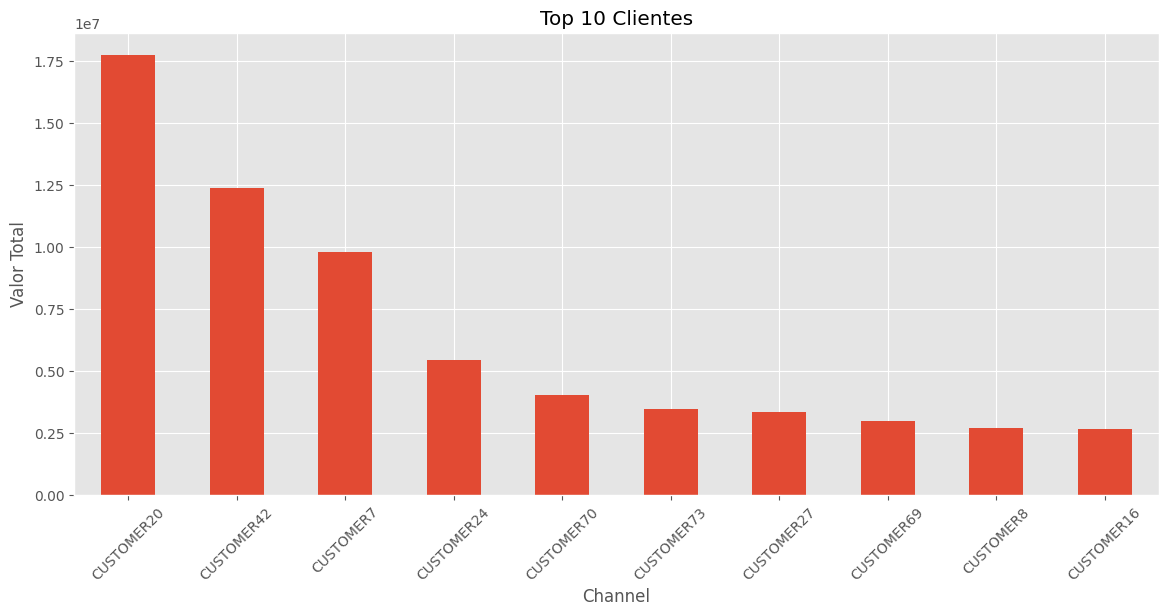

In [51]:
top_clientes = (
    df_total
    .groupby('Channel')['Valor']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

top_clientes.plot(kind='bar')

plt.title('Top 10 Clientes')

plt.ylabel('Valor Total')

plt.xticks(rotation=45)

plt.show()

#### Comportamiento Temporal por Categoría

Channel Inv. domina en escala (promedio semanal agregado ~481 mil vs ~64 mil en Cust. Sales y ~59 mil en Sell-in). Las tres series siguen el tiempo con ondas y picos, no una línea plana. Inventario suele ser más volátil y de mayor magnitud; ventas al consumidor y sell-in se mueven en niveles más bajos pero con patrones temporales propios.

Esta grafica nos permite visualizar la dinámica de la cadena de suministro: inventario en canal vs ventas reales vs despacho al distribuidor, y ayuda a no mezclar indicadores con magnitudes distintas.

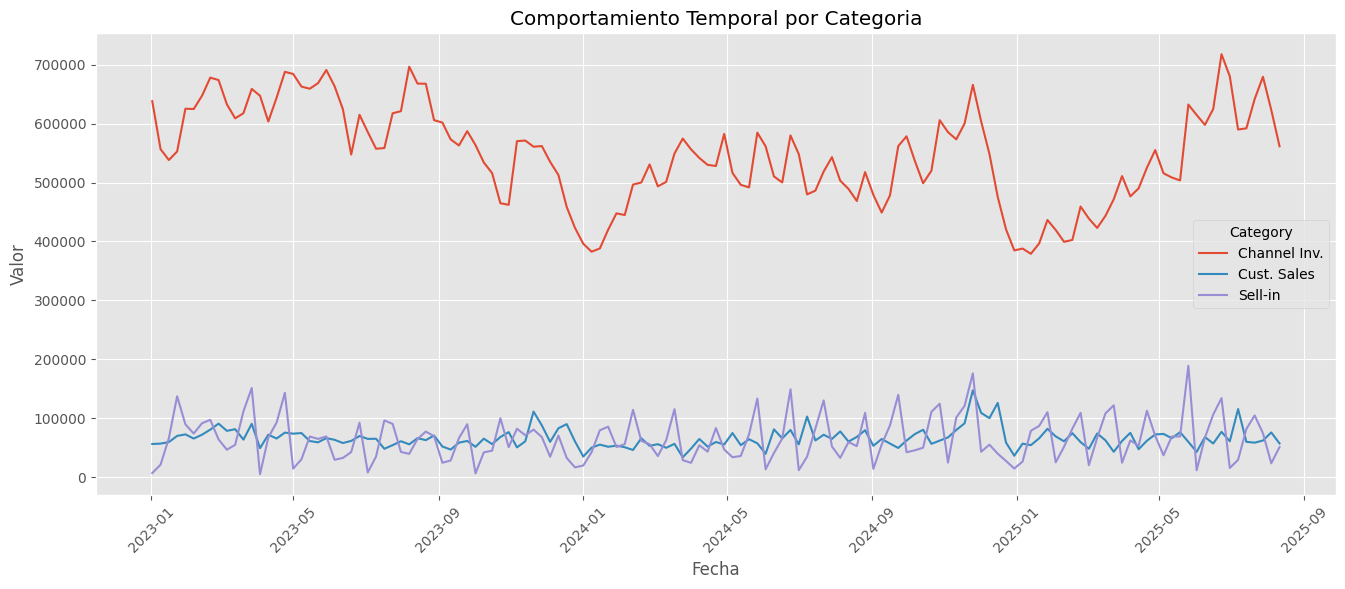

In [52]:
ventas_categoria = (
    df_total
    .groupby(
        ['Fecha', 'Category']
    )['Valor']
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

sns.lineplot(
    data=ventas_categoria,
    x='Fecha',
    y='Valor',
    hue='Category'
)

plt.title('Comportamiento Temporal por Categoria')

plt.xticks(rotation=45)

plt.show()

#### Comportamiento temporal general

La serie refleja el ciclo semanal agregado con subidas y bajadas. Hacia 2025 la trayectoria se acorta (menos semanas por el filtro de semanas 34–52) y el volumen acumulado del año es menor que 2023–2024 (~11–38 M según agregación), coherente con un año incompleto.

Nos permite ver si el negocio crece, cae o se estabiliza en el tiempo, antes de entrar al modelado

In [53]:
ventas_mensuales = (
    df_total
    .groupby('Fecha')['Valor']
    .sum()
    .reset_index()
)

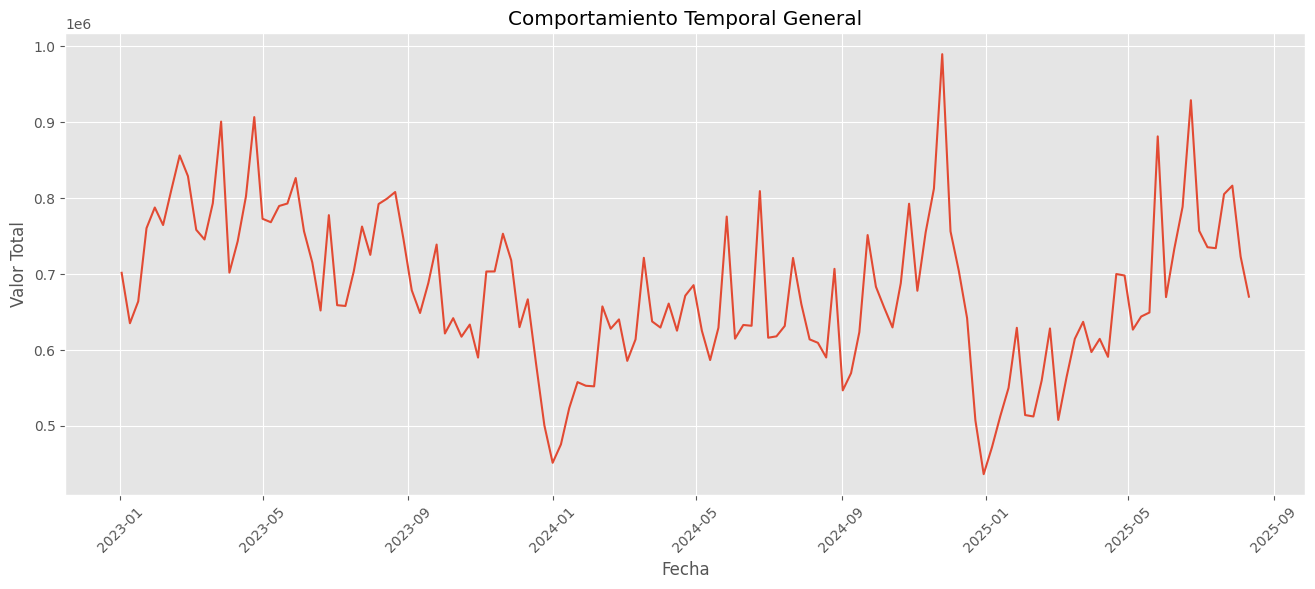

In [54]:
plt.figure(figsize=(16,6))

plt.plot(
    ventas_mensuales['Fecha'],
    ventas_mensuales['Valor']
)

plt.title('Comportamiento Temporal General')

plt.xlabel('Fecha')

plt.ylabel('Valor Total')

plt.xticks(rotation=45)

plt.show()

#### Distribución de Valor

La distribución es muy sesgada a la derecha y concentrada en cero: ~75 % de registros tienen valor 0. La barra más alta está en 0; luego hay cola larga hacia valores grandes (hasta decenas de miles en casos extremos). La mayoría de semanas no tienen movimiento para muchas combinaciones cliente–producto–categoría.

Este grafico nos explica por qué promedios y modelos pueden ser engañososes un dataset de demanda intermitente con muchos ceros y pocos picos.

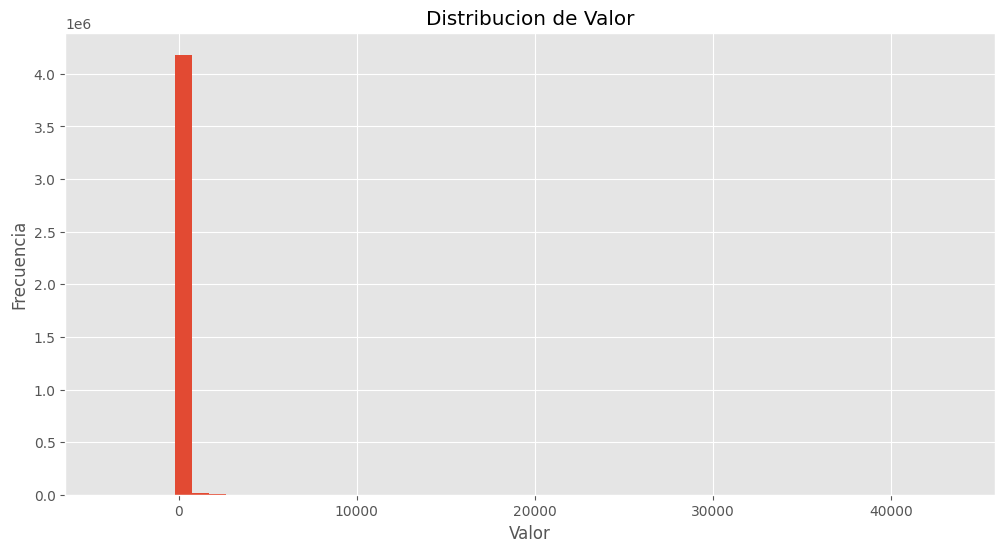

In [55]:
plt.figure(figsize=(12,6))

plt.hist(
    df_total['Valor'],
    bins=50
)

plt.title('Distribucion de Valor')

plt.xlabel('Valor')

plt.ylabel('Frecuencia')

plt.show()

#### Boxplot de Valor

El Bocplot nos muestra que la caja queda apretada cerca de cero (mediana 0) y hay muchos outliers hacia arriba y algunos negativos por ajustes/devoluciones. En el histograma se confirmapocos registros con volúmenes muy altos estiran la escala.




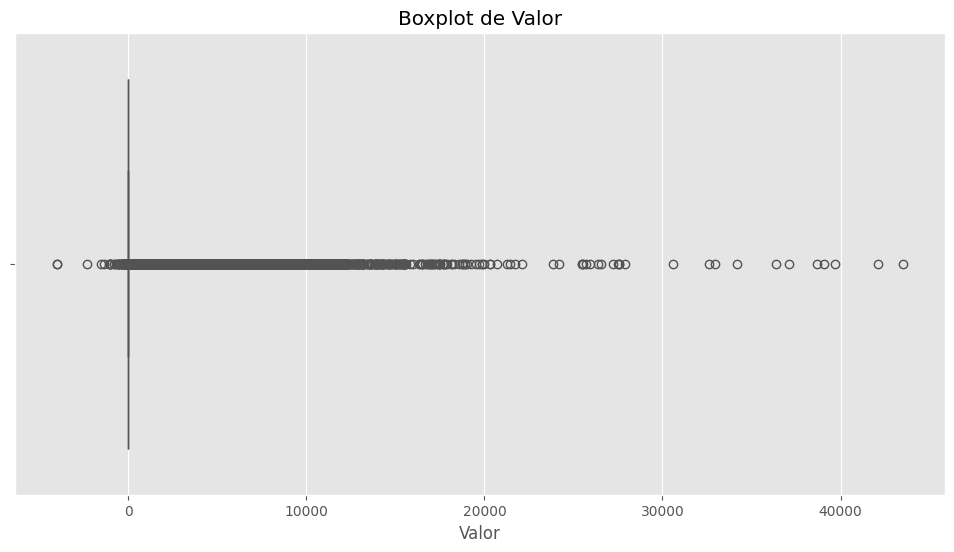

In [56]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df_total['Valor']
)

plt.title('Boxplot de Valor')

plt.show()

####  Boxplot valor por Categoría

Channel Inv. tiene caja más amplia, mediana en 0 pero más outliers altos (inventarios grandes). Cust. Sales y Sell-in tienen cajas similares, más compactas y también con mediana 0, con outliers menos extremos que inventario. Coherente con promedios ~53 vs ~6 unidades por registro.

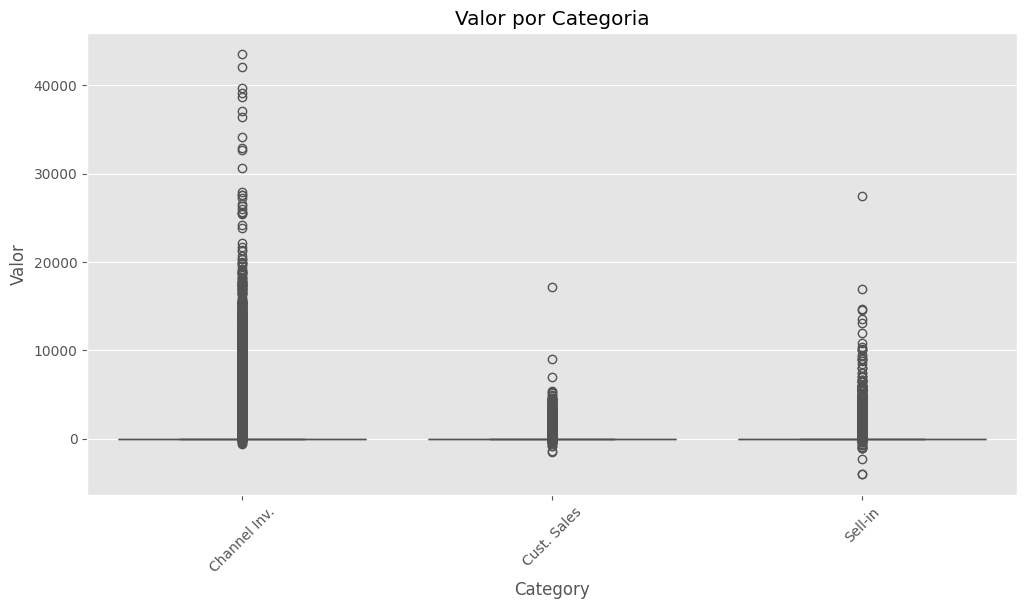

In [57]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_total,
    x='Category',
    y='Valor'
)

plt.title('Valor por Categoria')

plt.xticks(rotation=45)

plt.show()


### Comportamiento Semanas

Hay variación la semana 22 concentra el mayor volumen agregado (~2,4 M) y la 52 el menor (~1,0 M). No es plano algunas semanas del calendario sistemáticamente muestran más actividad puede ser un posible efecto estacional, promociones o cierres de periodo.

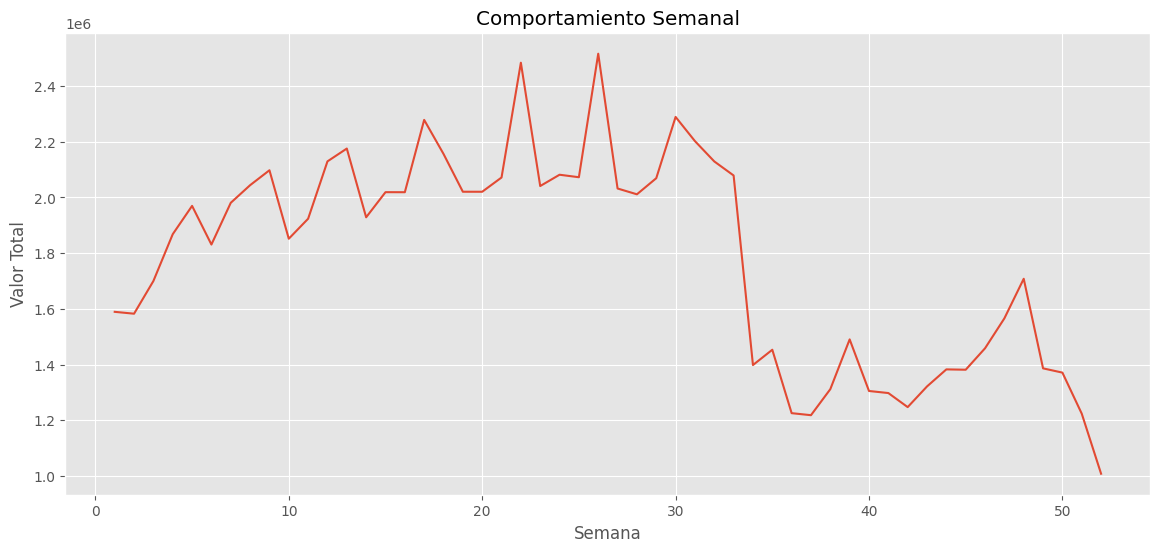

In [58]:
ventas_semana = (
    df_total
    .groupby('Semana')['Valor']
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    ventas_semana.index,
    ventas_semana.values
)

plt.title('Comportamiento Semanal')

plt.xlabel('Semana')

plt.ylabel('Valor Total')

plt.show()

#### Comportamiento Semanal por Año

Cada año tiene su curva semana a semana. 2023 y 2024 cubren las 52 semanas con patrones parecidos pero no idénticos. 2025 aparece como línea más corta solo hasta semana 33, con niveles que pueden verse distintos por el periodo parcial. Permite ver si la estacionalidad se repite año a año o cambia.


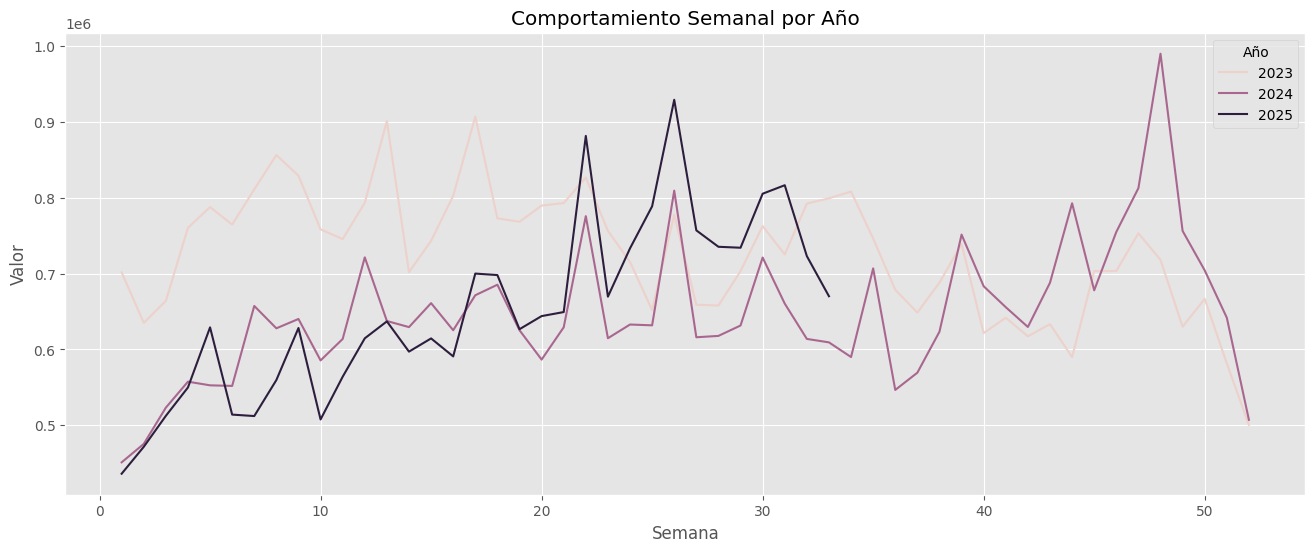

In [59]:
ventas_anio_semana = (
    df_total
    .groupby(['Año', 'Semana'])['Valor']
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

sns.lineplot(
    data=ventas_anio_semana,
    x='Semana',
    y='Valor',
    hue='Año'
)

plt.title('Comportamiento Semanal por Año')

plt.show()

#### Top 10 Tipos de Productos

MOBILE domina ampliamente (~50,9 M), más del doble que el segundo (LED TV, ~10,1 M). Siguen OWM, TABLET, QLED TV, etc. La mezcla del portafolio está muy concentrada en móviles y TVs.

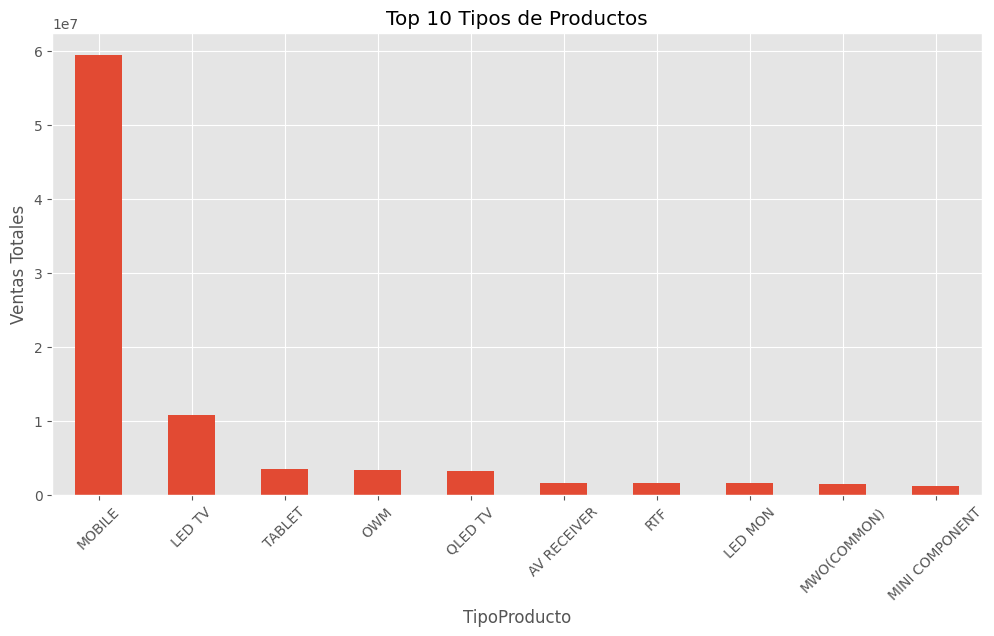

In [60]:
top_productos = (
    df_total
    .groupby('TipoProducto')['Valor']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_productos.plot(kind='bar')

plt.title('Top 10 Tipos de Productos')

plt.ylabel('Ventas Totales')

plt.xticks(rotation=45)

plt.show()

In [61]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4206567 entries, 0 to 4206566
Data columns (total 9 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Channel               object        
 1   Material Description  object        
 2   Category              object        
 3   Semana                int64         
 4   Valor                 int64         
 5   Año                   int64         
 6   TipoProducto          object        
 7   Fecha                 datetime64[ns]
 8   Mes                   int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(4)
memory usage: 272.8+ MB


#### Matriz Correlación (Año, Semana, Valor)

las correlaciones son prácticamente nulas entre Valor y Año (~−0,015) o Semana (-0,19). Año y Semana sí se correlacionan levemente (−0,19) por la estructura del panel temporal. El heatmap muestra que ni el año ni la semana explican solos el volumen en registros individuales.



Matriz de correlacion:
             Año    Semana     Valor
Año     1.000000 -0.189460  0.014511
Semana -0.189460  1.000000 -0.001818
Valor   0.014511 -0.001818  1.000000


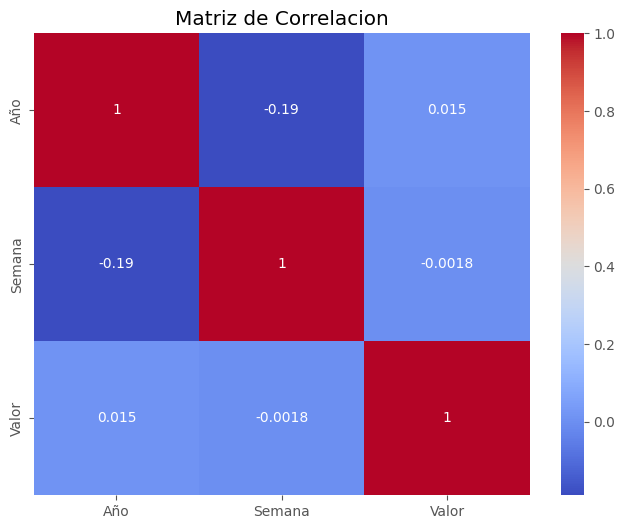

In [62]:
corr = df_total[
    ['Año', 'Semana', 'Valor',]
].corr()

print("\n")
print("Matriz de correlacion:")

print(corr)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlacion')

plt.show()

# Modelado Predictivo (Machine Learning)

## Modelo XGBRegressor

### PREPARACIÓN DEL DATASET DE FORECASTING

Tiene como objetivo construir la serie de ventas al consumidor y consolidar

In [63]:
df_forecast = df_total[
    (df_total['Category'] == 'Cust. Sales') &
    (df_total['Valor'] >= 0)
].copy()

df_forecast = (
    df_forecast
    .groupby(
        ['Channel', 'TipoProducto', 'Año', 'Semana', 'Fecha', 'Mes'],
        as_index=False
    )['Valor']
    .sum()
)

### Variables Temporales

Nos permiteepresentar correctamente la naturaleza circular
de las semanas del año.

In [64]:
df_forecast['semana_sin'] = np.sin(
    2 * np.pi * df_forecast['Semana'] / 52
)

df_forecast['semana_cos'] = np.cos(
    2 * np.pi * df_forecast['Semana'] / 52
)

### ORDENAMIENTO TEMPORAL

Objetivo:
Garantizar que los cálculos históricos respeten el orden cronológico.

In [65]:
df_forecast = df_forecast.sort_values(
    ['Channel', 'TipoProducto', 'Año', 'Semana']
)

### FEATURES HISTÓRICAS (LAGS)
Objetivo:
Permitir que el modelo utilice ventas pasadas para
predecir ventas futuras.

In [66]:
grupo = df_forecast.groupby(
    ['Channel', 'TipoProducto']
)['Valor']

df_forecast['lag_1'] = grupo.shift(1)
df_forecast['lag_2'] = grupo.shift(2)
df_forecast['lag_4'] = grupo.shift(4)
df_forecast['lag_8'] = grupo.shift(8)
df_forecast['lag_12'] = grupo.shift(12)

### TENDENCIA DE CORTO Y MEDIANO PLAZO
Objetivo:
Capturar el comportamiento reciente de ventas.

In [67]:
df_forecast['media_movil_4'] = (
    grupo.transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    )
)

df_forecast['media_movil_8'] = (
    grupo.transform(
        lambda x: x.shift(1).rolling(8, min_periods=1).mean()
    )
)

df_forecast['media_movil_12'] = (
    grupo.transform(
        lambda x: x.shift(1).rolling(12, min_periods=1).mean()
    )
)

### MEDIDAS DE VARIABILIDAD
Objetivo:
Indicar si el comportamiento histórico es estable
o altamente variable.


In [68]:
df_forecast['std_4'] = (
    grupo.transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).std()
    )
)

df_forecast['std_8'] = (
    grupo.transform(
        lambda x: x.shift(1).rolling(8, min_periods=1).std()
    )
)

df_forecast[['std_4', 'std_8']] = (
    df_forecast[['std_4', 'std_8']]
    .fillna(0)
)

###  CODIFICACIÓN DE VARIABLES CATEGÓRICAS
Objetivo:
Transformar variables categóricas a formato numérico.


In [69]:
from sklearn.preprocessing import LabelEncoder

le_channel = LabelEncoder()
le_producto = LabelEncoder()

df_forecast['Channel_enc'] = (
    le_channel.fit_transform(df_forecast['Channel'])
)

df_forecast['TipoProducto_enc'] = (
    le_producto.fit_transform(df_forecast['TipoProducto'])
)

### LIMPIEZA FINAL
Objetivo:
Eliminar registros sin suficiente historial.

In [70]:
lag_cols = [
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_8',
    'lag_12',
    'media_movil_4',
    'media_movil_8',
    'media_movil_12',
]

df_forecast = (
    df_forecast
    .dropna(subset=lag_cols)
    .reset_index(drop=True)
)

### DEFINICIÓN DE VARIABLES
Objetivo:
Definir predictores y variable objetivo.


In [71]:
features = [
    'Channel_enc',
    'TipoProducto_enc',
    'Año',
    'Semana',
    'Mes',
    'semana_sin',
    'semana_cos',
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_8',
    'lag_12',
    'media_movil_4',
    'media_movil_8',
    'media_movil_12',
    'std_4',
    'std_8'
]

target = 'Valor'

### PARTICIÓN TEMPORAL
Objetivo:
Separar entrenamiento, validación y prueba respetando
la secuencia temporal.

In [72]:
mask_val = (
    (df_forecast['Año'] == 2024) &
    (df_forecast['Semana'] > 40)
)

train = df_forecast[
    (~mask_val) &
    (df_forecast['Año'] < 2025)
]

validacion = df_forecast[
    mask_val
]

test = df_forecast[
    df_forecast['Año'] == 2025
]

X_train = train[features]
y_train = train[target]

X_val = validacion[features]
y_val = validacion[target]

X_test = test[features]
y_test = test[target]

### ENTRENAMIENTO DEL MODELO
Objetivo:
Ajustar un modelo XGBoost optimizado para forecasting.

In [73]:
import xgboost as xgb

modelo_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

modelo_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

### PREDICCIONES
Generar predicciones sobre el conjunto de prueba.


In [74]:
y_pred = modelo_xgb.predict(X_test)

### EVALUACIÓN DEL MODELO
Objetivo:
Medir precisión y capacidad predictiva.

In [75]:


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mask_nonzero = y_test != 0

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

mape = (
    np.mean(
        np.abs(
            (y_test[mask_nonzero] - y_pred[mask_nonzero])
            / y_test[mask_nonzero]
        )
    ) * 100
)

smape = (
    np.mean(
        2 * np.abs(y_pred - y_test)
        /
        (
            np.abs(y_test)
            + np.abs(y_pred)
            + 1e-8
        )
    ) * 100
)

pd.DataFrame({
    'MAE': [round(mae, 2)],
    'RMSE': [round(rmse, 2)],
    'R2': [round(r2, 4)],
    'MAPE_%': [round(mape, 2)],
    'SMAPE_%': [round(smape, 2)]
})

,MAE,RMSE,R2,MAPE_%,SMAPE_%
0,32.3,260.93,0.7848,130.67,122.21


### IMPORTANCIA DE VARIABLES
Objetivo:
Identificar qué factores explican más las ventas.


In [76]:


importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': modelo_xgb.feature_importances_
})

importancias = (
    importancias
    .sort_values(
        'Importancia',
        ascending=False
    )
)

importancias.head(15)

,Variable,Importancia
8,lag_2,0.157208
9,lag_4,0.151702
0,Channel_enc,0.140241
7,lag_1,0.121553
13,media_movil_8,0.118107
14,media_movil_12,0.092122
11,lag_12,0.082640
12,media_movil_4,0.051443
3,Semana,0.011824
2,Año,0.011805


### COMPARACIÓN REAL VS PREDICHO
Objetivo:
Analizar visualmente el comportamiento agregado.

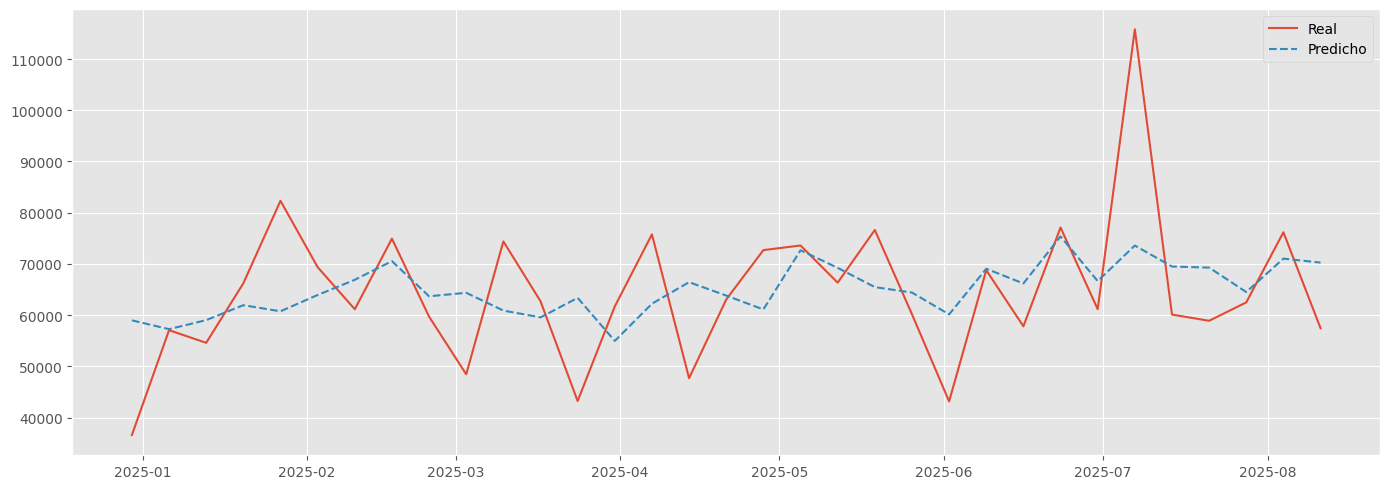

In [77]:
comparacion = pd.DataFrame({
    'Fecha': test['Fecha'],
    'Real': y_test,
    'Predicho': y_pred
})

comparacion = (
    comparacion
    .groupby('Fecha')
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    comparacion['Fecha'],
    comparacion['Real'],
    label='Real'
)

plt.plot(
    comparacion['Fecha'],
    comparacion['Predicho'],
    '--',
    label='Predicho'
)

plt.legend()
plt.tight_layout()
plt.show()

In [78]:
y_test.describe()

,Valor
count,29343.000000
mean,72.508298
std,562.422443
min,0.000000
25%,0.000000
50%,1.000000
75%,13.000000
max,19298.000000


In [79]:
(y_test == 0).mean() * 100

np.float64(47.82060457349282)

In [80]:
mask = y_test > 10

mae_alt = mean_absolute_error(
    y_test[mask],
    y_pred[mask]
)

rmse_alt = np.sqrt(
    mean_squared_error(
        y_test[mask],
        y_pred[mask]
    )
)

r2_alt = r2_score(
    y_test[mask],
    y_pred[mask]
)

print(mae_alt)
print(rmse_alt)
print(r2_alt)

106.75936126708984
488.5436105149672
0.7870774865150452


## Modelo XGBClassifier (CHURN)

In [85]:
# ============================================================
# 1. FILTRAR Y AGREGAR SOLO VENTAS AL CONSUMIDOR (Cust. Sales)
#    Es la métrica más relevante para predecir demanda real
#    Agregamos por cliente y tipo de producto para evitar sesgos
# ============================================================
df_ventas = df_total[df_total['Category'] == 'Cust. Sales'].copy()
df_ventas = df_ventas.groupby(['Channel', 'TipoProducto', 'Año', 'Semana', 'Fecha', 'Mes'], as_index=False)['Valor'].sum()

# ============================================================
# 2. FEATURES DE TIEMPO (el modelo necesita entender temporalidad)
# ============================================================
# Semana del año como ángulo → captura estacionalidad cíclica
# Ejemplo: semana 1 y semana 52 son "cercanas" en el año
df_ventas['semana_sin'] = np.sin(2 * np.pi * df_ventas['Semana'] / 52)
df_ventas['semana_cos'] = np.cos(2 * np.pi * df_ventas['Semana'] / 52)

# ============================================================
# 3. FEATURES DE HISTORIAL (lag features)
#    Le decimos al modelo: "la semana pasada se vendió X"
# ============================================================
df_ventas = df_ventas.sort_values(['Channel', 'TipoProducto', 'Año', 'Semana'])

# Ventas de semanas anteriores por cliente+producto
df_ventas['lag_1'] = df_ventas.groupby(['Channel', 'TipoProducto'])['Valor'].shift(1)
df_ventas['lag_2'] = df_ventas.groupby(['Channel', 'TipoProducto'])['Valor'].shift(2)
df_ventas['lag_4'] = df_ventas.groupby(['Channel', 'TipoProducto'])['Valor'].shift(4)

# Promedio móvil de las últimas 4 semanas
df_ventas['media_movil_4'] = (
    df_ventas
    .groupby(['Channel', 'TipoProducto'])['Valor']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

# ============================================================
# 4. CODIFICAR VARIABLES CATEGÓRICAS
#    XGBoost solo entiende números
# ============================================================
le_channel      = LabelEncoder()
le_tipoproducto = LabelEncoder()

df_ventas['Channel_enc']      = le_channel.fit_transform(df_ventas['Channel'])
df_ventas['TipoProducto_enc'] = le_tipoproducto.fit_transform(df_ventas['TipoProducto'])

# ============================================================
# 5. ELIMINAR FILAS CON NaN (generados por los lags)
# ============================================================
df_ventas = df_ventas.dropna(subset=['lag_1', 'lag_2', 'lag_4', 'media_movil_4'])

print(df_ventas.shape)
print(df_ventas[['Channel', 'TipoProducto', 'Año', 'Semana', 'lag_1', 'media_movil_4', 'Valor']].head(10))

(140902, 15)
      Channel TipoProducto   Año  Semana  lag_1  media_movil_4  Valor
4   CUSTOMER1       MOBILE  2023       5    0.0            0.0      0
5   CUSTOMER1       MOBILE  2023       6    0.0            0.0      0
6   CUSTOMER1       MOBILE  2023       7    0.0            0.0      0
7   CUSTOMER1       MOBILE  2023       8    0.0            0.0      0
8   CUSTOMER1       MOBILE  2023       9    0.0            0.0      0
9   CUSTOMER1       MOBILE  2023      10    0.0            0.0      0
10  CUSTOMER1       MOBILE  2023      11    0.0            0.0      0
11  CUSTOMER1       MOBILE  2023      12    0.0            0.0      0
12  CUSTOMER1       MOBILE  2023      13    0.0            0.0      0
13  CUSTOMER1       MOBILE  2023      14    0.0            0.0      0


### DEFINIR CHURN CON DATOS DE 2024
Un cliente-producto está en riesgo si sus últimas 4 semanas
disponibles en 2024 tienen Valor = 0.
Se usa 2024 (no todo el dataset) para evitar data leakage.

In [86]:
df_2024 = df_ventas[df_ventas['Año'] == 2024].copy()

ultimas_4 = (
    df_2024
    .sort_values(['Channel', 'TipoProducto', 'Semana'])
    .groupby(['Channel', 'TipoProducto'])
    .tail(4)
)

churn_flags = (
    ultimas_4
    .groupby(['Channel', 'TipoProducto'])['Valor']
    .apply(lambda x: int((x == 0).all() and len(x) == 4))
    .reset_index()
    .rename(columns={'Valor': 'churn'})
)

n_riesgo  = churn_flags['churn'].sum()
n_activos = (churn_flags['churn'] == 0).sum()
print(f"Clientes-producto en riesgo : {n_riesgo}")
print(f"Clientes-producto activos   : {n_activos}")
print(f"Tasa de churn               : {n_riesgo / (n_riesgo + n_activos) * 100:.1f}%")

Clientes-producto en riesgo : 443
Clientes-producto activos   : 622
Tasa de churn               : 41.6%


### UNIR LABEL Y SPLIT TEMPORAL

Train: 2023 + primeras 40 semanas de 2024
Test : 2025
El label (churn) viene de fin de 2024, así que el modelo
de train aprende "¿qué perfil lleva a dejar de comprar?"

In [87]:
features = [
    'Channel_enc',
    'TipoProducto_enc',
    'Año',
    'Semana',
    'semana_sin',
    'semana_cos',
    'lag_1',
    'lag_2',
    'lag_4',
    'media_movil_4'
]

target = 'Valor'

In [88]:
df_churn = df_ventas.merge(churn_flags, on=['Channel', 'TipoProducto'], how='inner')

mask_val_c = (df_churn['Año'] == 2024) & (df_churn['Semana'] > 40)

train_c = df_churn[~mask_val_c & (df_churn['Año'] < 2025)]
test_c  = df_churn[df_churn['Año'] == 2025]

X_c_train = train_c[features]
y_c_train = train_c['churn']
X_c_test  = test_c[features]
y_c_test  = test_c['churn']

print(f"\nTrain churn: {X_c_train.shape} | Test churn: {X_c_test.shape}")
print(f"Distribución train: {y_c_train.value_counts().to_dict()}")
print(f"Distribución test : {y_c_test.value_counts().to_dict()}")


Train churn: (83840, 10) | Test churn: (29073, 10)
Distribución train: {0: 51200, 1: 32640}
Distribución test : {0: 20097, 1: 8976}


### ENTRENAR CLASIFICADOR
scale_pos_weight: si hay 9 activos por cada 1 en riesgo,
le decimos al modelo que equivocarse en churn=1 pesa 9x más.
Evita que el modelo diga "nadie hace churn" y tenga
90% de accuracy sin aprender nada real.


In [89]:
n0 = (y_c_train == 0).sum()
n1 = (y_c_train == 1).sum()
ratio = n0 / max(n1, 1)

print(f"\nscale_pos_weight usado: {ratio:.2f}")

modelo_churn = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

modelo_churn.fit(X_c_train, y_c_train)


scale_pos_weight usado: 1.57


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

### MÉTRICAS DEL CLASIFICADOR
Para churn, las métricas clave son:
Recall en "En riesgo": ¿cuántos clientes en riesgo detectamos?
Precision en "En riesgo": ¿cuántas alarmas son reales?
AUC-ROC: capacidad general de separar las dos clases



  MÉTRICAS DE EVALUACIÓN — XGBoost Churn
              precision    recall  f1-score   support

      Activo       0.94      0.88      0.91     20097
   En riesgo       0.77      0.88      0.82      8976

    accuracy                           0.88     29073
   macro avg       0.86      0.88      0.87     29073
weighted avg       0.89      0.88      0.88     29073

  AUC-ROC: 0.9540
  Interpretación: EXCELENTE discriminación


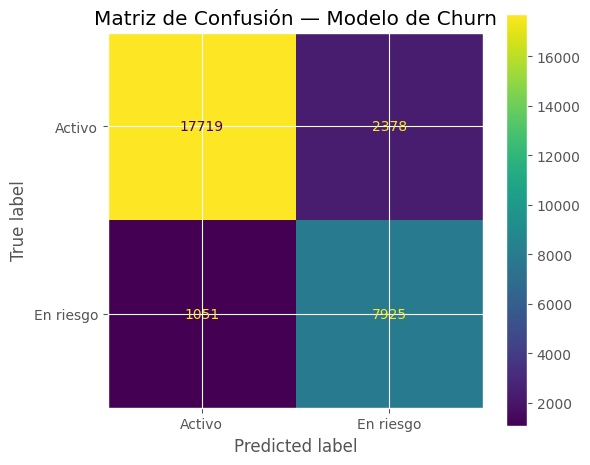

In [90]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

y_churn_pred  = modelo_churn.predict(X_c_test)
y_churn_proba = modelo_churn.predict_proba(X_c_test)[:, 1]

print("\n" + "="*55)
print("  MÉTRICAS DE EVALUACIÓN — XGBoost Churn")
print("="*55)
print(classification_report(
    y_c_test, y_churn_pred,
    target_names=['Activo', 'En riesgo'],
    zero_division=0
))

try:
    auc = roc_auc_score(y_c_test, y_churn_proba)
    print(f"  AUC-ROC: {auc:.4f}")
    if auc >= 0.85:
        print("  Interpretación: EXCELENTE discriminación")
    elif auc >= 0.70:
        print("  Interpretación: BUENO — útil para priorizar acciones")
    else:
        print("  Interpretación: MODERADO — revisar definición de churn")
except Exception as e:
    print(f"  AUC-ROC no calculable: {e}")
print("="*55)

# Matriz de confusión
cm = confusion_matrix(y_c_test, y_churn_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Activo', 'En riesgo']).plot(ax=ax)
plt.title('Matriz de Confusión — Modelo de Churn')
plt.tight_layout()
plt.show()

### SALIDA ACCIONABLE
clientes en riesgo ordenados
por probabilidad, para que el equipo comercial priorice


In [91]:
resultado = test_c[['Channel', 'TipoProducto']].copy().reset_index(drop=True)
resultado['churn_pred']           = y_churn_pred
resultado['probabilidad_churn_%'] = (y_churn_proba * 100).round(1)

clientes_riesgo = (
    resultado[resultado['churn_pred'] == 1]
    .drop_duplicates(subset=['Channel', 'TipoProducto'])
    .sort_values('probabilidad_churn_%', ascending=False)
)

print(f"\nClientes-producto en riesgo detectados: {len(clientes_riesgo)}")
print("\nTop 15 — mayor probabilidad de churn:")
print(clientes_riesgo[['Channel', 'TipoProducto', 'probabilidad_churn_%']].head(15).to_string(index=False))


Clientes-producto en riesgo detectados: 464

Top 15 — mayor probabilidad de churn:
   Channel        TipoProducto  probabilidad_churn_%
CUSTOMER12  SIGNAGE_STANDALONE             99.800003
CUSTOMER12         BUSINESS TV             99.800003
CUSTOMER12                 LFD             99.599998
CUSTOMER12           LED TV(H)             99.599998
CUSTOMER97              MOBILE             99.400002
 CUSTOMER3                 CAC             98.900002
 CUSTOMER3                 DVM             98.699997
 CUSTOMER3                 PMA             98.500000
CUSTOMER65 BLU-RAY DISC PLAYER             98.099998
CUSTOMER25              TABLET             98.099998
CUSTOMER15                 RSD             97.699997
CUSTOMER30              LED TV             97.599998
CUSTOMER97              LED TV             97.500000
CUSTOMER50 BLU-RAY DISC PLAYER             97.400002
CUSTOMER86                 RSD             97.300003


In [92]:
# Métricas solo sobre semanas con venta real (excluir ceros)
mask_activo = y_test > 0
mae_activo  = mean_absolute_error(y_test[mask_activo], y_pred[mask_activo])
r2_activo   = r2_score(y_test[mask_activo], y_pred[mask_activo])
print(f"MAE solo en semanas con venta : {mae_activo:.2f} unidades")
print(f"R²  solo en semanas con venta : {r2_activo:.4f}")

MAE solo en semanas con venta : 57.73 unidades
R²  solo en semanas con venta : 0.7918



## MODELO LSTM AVANZADO (Embeddings + Log Transform)



In [93]:
# Importaciones adicionales para LSTM Multi-Input
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Embedding, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Verificar si TensorFlow detecta GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [94]:
# ============================================================
# PASO 1: PREPARACIÓN DE DATOS SECUENCIALES Y LOGARÍTMICOS
# ============================================================
df_lstm = df_total[df_total['Category'] == 'Cust. Sales'].copy()
df_lstm = df_lstm.groupby(['Channel', 'TipoProducto', 'Año', 'Semana', 'Fecha', 'Mes'], as_index=False)['Valor'].sum()
df_lstm = df_lstm.sort_values(['Channel', 'TipoProducto', 'Año', 'Semana'])

# CORRECCIÓN IMPORTANTE: Las devoluciones o ajustes generan valores de venta negativos.
# El logaritmo (np.log1p) de un número negativo produce NaN (Not a Number), lo cual
# rompe el modelo. Como queremos predecir la demanda real, reemplazamos valores negativos por 0.
df_lstm['Valor'] = df_lstm['Valor'].clip(lower=0)

# 1. Transformación Logarítmica: CRÍTICO para ventas.
# Reduce el impacto de valores extremos y hace que el modelo aprenda mejor las proporciones.
df_lstm['Valor_Log'] = np.log1p(df_lstm['Valor'])

# 2. Añadir variables temporales cíclicas
df_lstm['semana_sin'] = np.sin(2 * np.pi * df_lstm['Semana'] / 52)
df_lstm['semana_cos'] = np.cos(2 * np.pi * df_lstm['Semana'] / 52)

# 3. Codificar las variables categóricas para usarlas en Embeddings
le_c = LabelEncoder()
le_p = LabelEncoder()
df_lstm['Channel_enc'] = le_c.fit_transform(df_lstm['Channel'])
df_lstm['TipoProducto_enc'] = le_p.fit_transform(df_lstm['TipoProducto'])

num_channels = len(le_c.classes_)
num_products = len(le_p.classes_)

# 4. Escalar solo las features numéricas temporales
features_seq = ['Valor_Log', 'semana_sin', 'semana_cos']
scaler_seq = MinMaxScaler()
df_lstm[features_seq] = scaler_seq.fit_transform(df_lstm[features_seq])


In [95]:
# ============================================================
# PASO 2: CREACIÓN DE VENTANAS MULTI-INPUT (SEQUENCES)
# ============================================================
LOOKBACK = 8  # Semanas anteriores para observar

def create_sequences_multi_input(df, seq_cols, target_col, lookback):
    X_seq, X_chan, X_prod, y, years, weeks = [], [], [], [], [], []

    for (channel, prod), group in df.groupby(['Channel_enc', 'TipoProducto_enc']):
        group = group.sort_values('Fecha')
        data_seq = group[seq_cols].values
        data_y = group[target_col].values
        anios = group['Año'].values
        semanas = group['Semana'].values

        if len(data_seq) <= lookback:
            continue

        for i in range(len(data_seq) - lookback):
            X_seq.append(data_seq[i:(i + lookback)])
            X_chan.append(channel)
            X_prod.append(prod)
            y.append(data_y[i + lookback])
            years.append(anios[i + lookback])
            weeks.append(semanas[i + lookback])

    return (np.array(X_seq), np.array(X_chan).reshape(-1, 1), np.array(X_prod).reshape(-1, 1),
            np.array(y), np.array(years), np.array(weeks))

# Target será Valor_Log, y luego le aplicaremos expm1() al final
X_seq, X_chan, X_prod, y_log, seq_years, seq_weeks = create_sequences_multi_input(
    df_lstm, features_seq, 'Valor_Log', LOOKBACK
)

print(f"Forma de X_seq: {X_seq.shape}")
print(f"Forma de X_chan: {X_chan.shape}")
print(f"Forma de y_log: {y_log.shape}")

Forma de X_seq: (135354, 8, 3)
Forma de X_chan: (135354, 1)
Forma de y_log: (135354,)


In [96]:
# ============================================================
# PASO 3: PARTICIÓN DE DATOS TEMPORAL
# ============================================================
mask_val_seq = (seq_years == 2024) & (seq_weeks > 40)
mask_test_seq = (seq_years == 2025)
mask_train_seq = (~mask_val_seq) & (~mask_test_seq)

# Train
X_train_seq = X_seq[mask_train_seq]
X_train_chan = X_chan[mask_train_seq]
X_train_prod = X_prod[mask_train_seq]
y_train_log = y_log[mask_train_seq]

# Val
X_val_seq = X_seq[mask_val_seq]
X_val_chan = X_chan[mask_val_seq]
X_val_prod = X_prod[mask_val_seq]
y_val_log = y_log[mask_val_seq]

# Test
X_test_seq = X_seq[mask_test_seq]
X_test_chan = X_chan[mask_test_seq]
X_test_prod = X_prod[mask_test_seq]
y_test_log = y_log[mask_test_seq]

# Las variables reales originales para validación de métricas finales (deslogaritmizadas)
y_test_real = np.expm1(y_test_log)

In [97]:
# ============================================================
# PASO 4: ARQUITECTURA MULTI-INPUT (EMBEDDINGS + LSTM)
# ============================================================
tf.random.set_seed(42)

# Entradas
input_seq = Input(shape=(LOOKBACK, len(features_seq)), name='Secuencia_Tiempo')
input_chan = Input(shape=(1,), name='Canal')
input_prod = Input(shape=(1,), name='Producto')

# Embeddings (Para que la red entienda la diferencia entre clientes y productos)
emb_chan = Embedding(input_dim=num_channels, output_dim=4, name='Emb_Canal')(input_chan)
emb_chan = Flatten()(emb_chan)

emb_prod = Embedding(input_dim=num_products, output_dim=16, name='Emb_Producto')(input_prod)
emb_prod = Flatten()(emb_prod)

# LSTM para la serie de tiempo
lstm_out = LSTM(64, return_sequences=True)(input_seq)
lstm_out = Dropout(0.2)(lstm_out)
lstm_out = LSTM(32, return_sequences=False)(lstm_out)

# Concatenar conocimiento temporal con conocimiento del producto y cliente
concat = Concatenate()([lstm_out, emb_chan, emb_prod])

# Capas Densas Finales
dense = Dense(32, activation='relu')(concat)
dense = Dropout(0.2)(dense)
output = Dense(1, activation='linear', name='Prediccion_Log')(dense)

modelo_lstm = Model(inputs=[input_seq, input_chan, input_prod], outputs=output)

modelo_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

modelo_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Secuencia_Tiempo    │ (None, 8, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 8, 64)     │     17,408 │ Secuencia_Tiempo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Canal (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Producto            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8, 64)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Emb_Canal           │ (None, 1, 4)      │        392 │ Canal[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Emb_Producto        │ (None, 1, 16)     │      1,216 │ Producto[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ Emb_Canal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ Emb_Producto[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 52)        │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,696 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Prediccion_Log      │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,161 (129.54 KB)

 Trainable params: 33,161 (129.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0064 - mae: 0.0500 - val_loss: 0.0045 - val_mae: 0.0422
Epoch 2/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0045 - mae: 0.0433 - val_loss: 0.0041 - val_mae: 0.0396
Epoch 3/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0043 - mae: 0.0426 - val_loss: 0.0041 - val_mae: 0.0377
Epoch 4/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0041 - mae: 0.0419 - val_loss: 0.0040 - val_mae: 0.0390
Epoch 5/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0040 - mae: 0.0415 - val_loss: 0.0040 - val_mae: 0.0395
Epoch 6/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0040 - mae: 0.0414 - val_loss: 0.0040 - val_mae: 0.0384
Epoch 7/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - loss: 0.0040 - mae: 0.0413 - val_loss: 0.0039 - val_mae: 0.0389
Epoch 8/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0040 - mae: 0.0412 - val_loss: 0.0039 - val_mae: 0.0372
Epoch 9/100
728/728 ━━━━━━━━━━━━

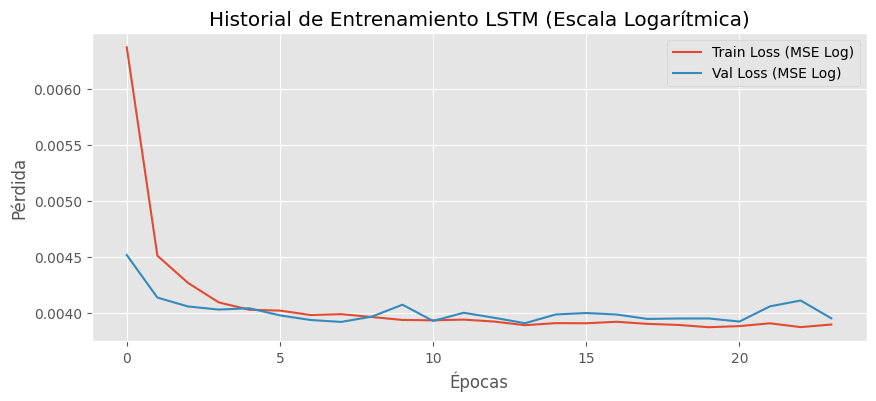

In [98]:
# ============================================================
# PASO 5: ENTRENAMIENTO DEL MODELO CON EARLY STOPPING
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

historial = modelo_lstm.fit(
    {'Secuencia_Tiempo': X_train_seq, 'Canal': X_train_chan, 'Producto': X_train_prod},
    y_train_log,
    epochs=100,
    batch_size=128,
    validation_data=({'Secuencia_Tiempo': X_val_seq, 'Canal': X_val_chan, 'Producto': X_val_prod}, y_val_log),
    callbacks=[early_stop],
    verbose=1
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(historial.history['loss'], label='Train Loss (MSE Log)')
plt.plot(historial.history['val_loss'], label='Val Loss (MSE Log)')
plt.title('Historial de Entrenamiento LSTM (Escala Logarítmica)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

In [99]:
# ============================================================
# PASO 6: EVALUACIÓN (INVIRTIENDO EL LOGARITMO)
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predecimos en escala logarítmica
y_pred_log = modelo_lstm.predict({'Secuencia_Tiempo': X_test_seq, 'Canal': X_test_chan, 'Producto': X_test_prod})

# Transformamos de vuelta a unidades de venta reales usando expm1 (Exponencial - 1)
y_pred_real = np.expm1(y_pred_log.flatten())

# Evitar negativos por si acaso
y_pred_real = np.maximum(y_pred_real, 0)

# Calcular métricas con y_test_real (que calculamos en el Paso 3)
mask_nonzero = y_test_real != 0

mae_lstm = mean_absolute_error(y_test_real, y_pred_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_lstm = r2_score(y_test_real, y_pred_real)
mape_lstm = np.mean(np.abs((y_test_real[mask_nonzero] - y_pred_real[mask_nonzero]) / y_test_real[mask_nonzero])) * 100
smape_lstm = np.mean(2 * np.abs(y_pred_real - y_test_real) / (np.abs(y_test_real) + np.abs(y_pred_real) + 1e-8)) * 100

print("" + "="*55)
print("  MÉTRICAS DE EVALUACIÓN — Modelo LSTM (V2 - Embeddings)")
print("="*55)
print(f"  MAE   (error promedio en unidades) : {mae_lstm:.2f}")
print(f"  RMSE  (penaliza errores grandes)   : {rmse_lstm:.2f}")
print(f"  R²    (varianza explicada)         : {r2_lstm:.4f}  ({r2_lstm*100:.1f}%)")
print(f"  MAPE  (error % sobre no-cero)      : {mape_lstm:.2f}%")
print(f"  SMAPE (error % simétrico)          : {smape_lstm:.2f}%")
print("="*55)

919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
  MÉTRICAS DE EVALUACIÓN — Modelo LSTM (V2 - Embeddings)
  MAE   (error promedio en unidades) : 0.05
  RMSE  (penaliza errores grandes)   : 0.09
  R²    (varianza explicada)         : 0.8755  (87.6%)
  MAPE  (error % sobre no-cero)      : 32.06%
  SMAPE (error % simétrico)          : 110.43%


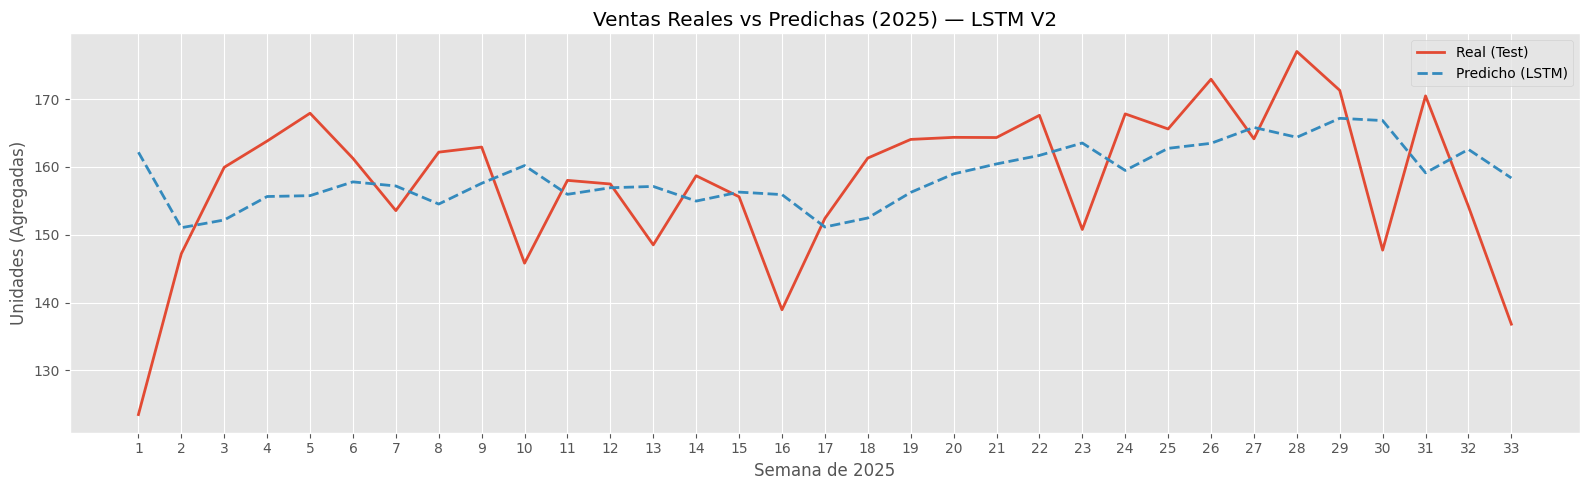

In [100]:
# ============================================================
# PASO 7: VISUALIZACIÓN REAL VS PREDICHO
# ============================================================
import pandas as pd

df_fechas_test = pd.DataFrame({
    'Semana_num': seq_weeks[mask_test_seq],
    'Real': y_test_real,
    'Predicho': y_pred_real
})

comparacion_lstm = df_fechas_test.groupby('Semana_num').sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(comparacion_lstm['Semana_num'], comparacion_lstm['Real'], label='Real (Test)', linewidth=2)
plt.plot(comparacion_lstm['Semana_num'], comparacion_lstm['Predicho'], label='Predicho (LSTM)', linewidth=2, linestyle='--')
plt.title('Ventas Reales vs Predichas (2025) — LSTM V2')
plt.xlabel('Semana de 2025')
plt.ylabel('Unidades (Agregadas)')
plt.legend()
plt.xticks(comparacion_lstm['Semana_num'])
plt.tight_layout()
plt.show()